In [2]:
# Cell 1 — Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# File paths
DATA_PATH = "data/processed/"

nav_df          = pd.read_csv(DATA_PATH + "nav_history_clean.csv")
aum_df          = pd.read_csv(DATA_PATH + "aum_by_fund_house_clean.csv")
benchmark_df    = pd.read_csv(DATA_PATH + "benchmark_indices_clean.csv")
performance_df  = pd.read_csv(DATA_PATH + "scheme_performance_clean.csv")
fund_master_df  = pd.read_csv(DATA_PATH + "fund_master_clean.csv")

nav_df['date'] = pd.to_datetime(nav_df['date'])

print("✅ All datasets loaded!")
print(f"NAV records: {len(nav_df):,}")
print(f"Benchmark records: {len(benchmark_df):,}")

✅ All datasets loaded!
NAV records: 46,000
Benchmark records: 8,050


In [3]:
print(benchmark_df.columns.tolist())
print(benchmark_df.head(2))

['date', 'index_name', 'close_value']
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64


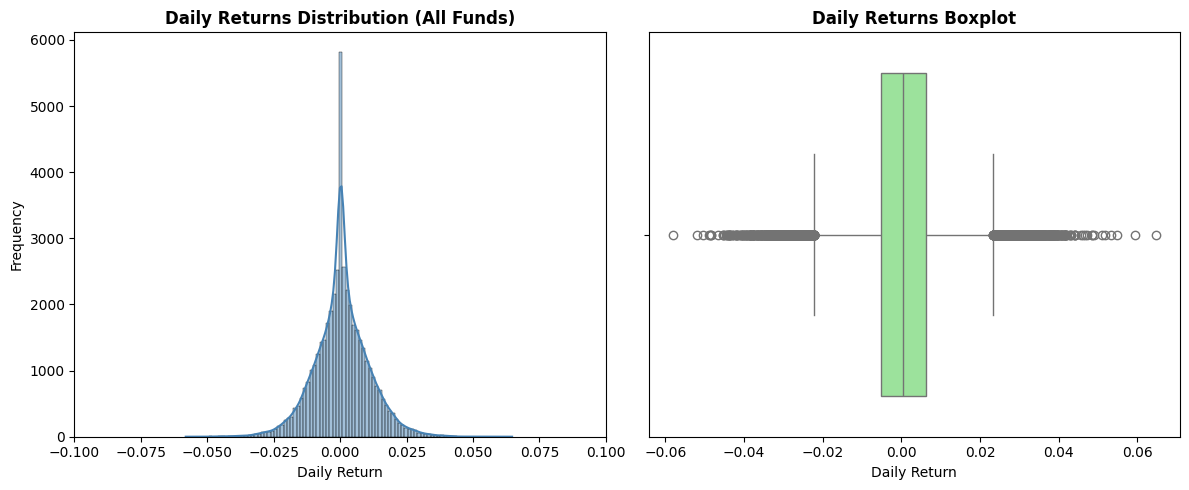

✅ Daily returns computed!
Mean daily return: 0.0006
Std daily return: 0.0103
Min: -0.0581 | Max: 0.0647


In [4]:
# Cell 2 — Compute Daily Returns for all schemes
nav_df = nav_df.sort_values(['amfi_code', 'date'])
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

# Drop NaN returns
returns_df = nav_df.dropna(subset=['daily_return']).copy()

# Validate distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(returns_df['daily_return'], bins=100, kde=True, color='steelblue')
plt.title('Daily Returns Distribution (All Funds)', fontweight='bold')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.xlim(-0.1, 0.1)

plt.subplot(1, 2, 2)
sns.boxplot(x=returns_df['daily_return'], color='lightgreen')
plt.title('Daily Returns Boxplot', fontweight='bold')
plt.xlabel('Daily Return')

plt.tight_layout()
import os
os.makedirs("charts", exist_ok=True)
plt.savefig('charts/daily_returns_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Daily returns computed!")
print(f"Mean daily return: {returns_df['daily_return'].mean():.4f}")
print(f"Std daily return: {returns_df['daily_return'].std():.4f}")
print(f"Min: {returns_df['daily_return'].min():.4f} | Max: {returns_df['daily_return'].max():.4f}")

In [5]:
# Cell 3 — CAGR for 1yr, 3yr, 5yr
def compute_cagr(group, years):
    group = group.sort_values('date')
    end_date = group['date'].max()
    start_date = end_date - pd.DateOffset(years=years)
    subset = group[group['date'] >= start_date]
    if len(subset) < 2:
        return np.nan
    nav_start = subset.iloc[0]['nav']
    nav_end = subset.iloc[-1]['nav']
    return (nav_end / nav_start) ** (1 / years) - 1

cagr_1yr = nav_df.groupby('amfi_code').apply(lambda x: compute_cagr(x, 1)).reset_index()
cagr_1yr.columns = ['amfi_code', 'cagr_1yr']

cagr_3yr = nav_df.groupby('amfi_code').apply(lambda x: compute_cagr(x, 3)).reset_index()
cagr_3yr.columns = ['amfi_code', 'cagr_3yr']

cagr_5yr = nav_df.groupby('amfi_code').apply(lambda x: compute_cagr(x, 5)).reset_index()
cagr_5yr.columns = ['amfi_code', 'cagr_5yr']

# Merge into one table
cagr_df = cagr_1yr.merge(cagr_3yr, on='amfi_code').merge(cagr_5yr, on='amfi_code')
cagr_df[['cagr_1yr', 'cagr_3yr', 'cagr_5yr']] = cagr_df[['cagr_1yr', 'cagr_3yr', 'cagr_5yr']].round(4)

# Merge scheme names
cagr_df = cagr_df.merge(performance_df[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
cagr_df = cagr_df[['amfi_code', 'scheme_name', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr']]

print("✅ CAGR computed!")
print(cagr_df.to_string(index=False))

✅ CAGR computed!
 amfi_code                                           scheme_name  cagr_1yr  cagr_3yr  cagr_5yr
    100016             HDFC Top 100 Fund - Regular Plan - Growth   -0.0222    0.0129    0.0232
    100025          HDFC Short Term Debt Fund - Regular - Growth    0.0370    0.0392    0.0391
    100033    HDFC Mid-Cap Opportunities Fund - Regular - Growth    0.5323    0.3244    0.2607
    101206         ABSL Frontline Equity Fund - Regular - Growth    0.4792    0.2897    0.2044
    101207                ABSL Small Cap Fund - Regular - Growth   -0.2399   -0.0415    0.0695
    101208                   ABSL Liquid Fund - Regular - Growth    0.0724    0.0632    0.0571
    102885            UTI Nifty 50 Index Fund - Regular - Growth    0.2021    0.1967    0.1588
    102886                   UTI Mid Cap Fund - Regular - Growth   -0.1680   -0.0077    0.0103
    102887                 UTI Flexi Cap Fund - Regular - Growth    0.1358    0.2556    0.1468
    118632        Nippon India La

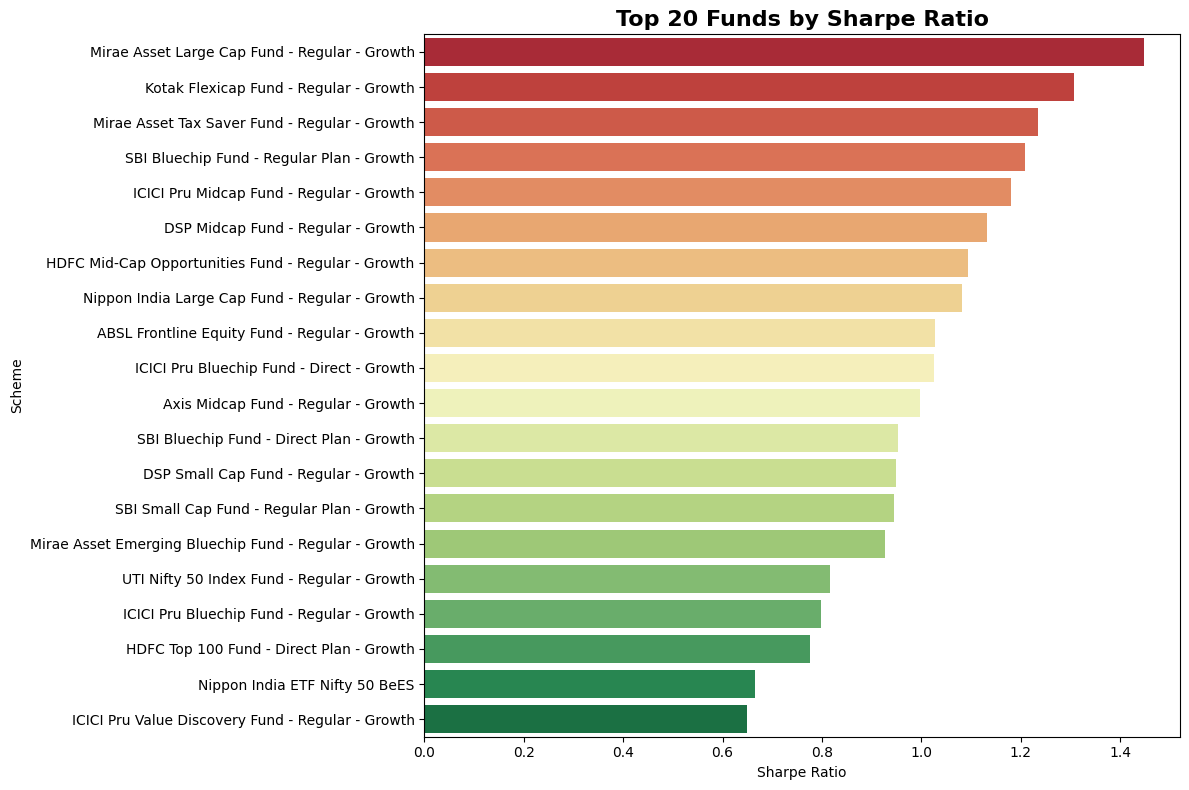

✅ Sharpe Ratio computed!
 amfi_code                                           scheme_name  sharpe_ratio  sharpe_rank
    148567         Mirae Asset Large Cap Fund - Regular - Growth        1.4483            1
    120843                Kotak Flexicap Fund - Regular - Growth        1.3067            2
    148569         Mirae Asset Tax Saver Fund - Regular - Growth        1.2349            3
    119551             SBI Bluechip Fund - Regular Plan - Growth        1.2083            4
    120505              ICICI Pru Midcap Fund - Regular - Growth        1.1801            5
    149323                    DSP Midcap Fund - Regular - Growth        1.1321            6
    100033    HDFC Mid-Cap Opportunities Fund - Regular - Growth        1.0937            7
    118632        Nippon India Large Cap Fund - Regular - Growth        1.0817            8
    101206         ABSL Frontline Equity Fund - Regular - Growth        1.0272            9
    120504             ICICI Pru Bluechip Fund - Direct

In [6]:
# Cell 4 — Sharpe Ratio
RF = 0.065 / 252  # Daily risk-free rate

sharpe_df = returns_df.groupby('amfi_code')['daily_return'].agg(
    mean_return='mean',
    std_return='std'
).reset_index()

sharpe_df['sharpe_ratio'] = (sharpe_df['mean_return'] - RF) / sharpe_df['std_return'] * np.sqrt(252)
sharpe_df = sharpe_df.sort_values('sharpe_ratio', ascending=False).reset_index(drop=True)
sharpe_df['sharpe_rank'] = sharpe_df['sharpe_ratio'].rank(ascending=False).astype(int)

# Merge scheme names
sharpe_df = sharpe_df.merge(performance_df[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
sharpe_df = sharpe_df[['amfi_code', 'scheme_name', 'sharpe_ratio', 'sharpe_rank']].round(4)

# Plot top 20
plt.figure(figsize=(12, 8))
top20_sharpe = sharpe_df.head(20)
sns.barplot(data=top20_sharpe, x='sharpe_ratio', y='scheme_name', palette='RdYlGn')
plt.title('Top 20 Funds by Sharpe Ratio', fontsize=16, fontweight='bold')
plt.xlabel('Sharpe Ratio')
plt.ylabel('Scheme')
plt.tight_layout()
plt.savefig('charts/sharpe_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Sharpe Ratio computed!")
print(sharpe_df.to_string(index=False))

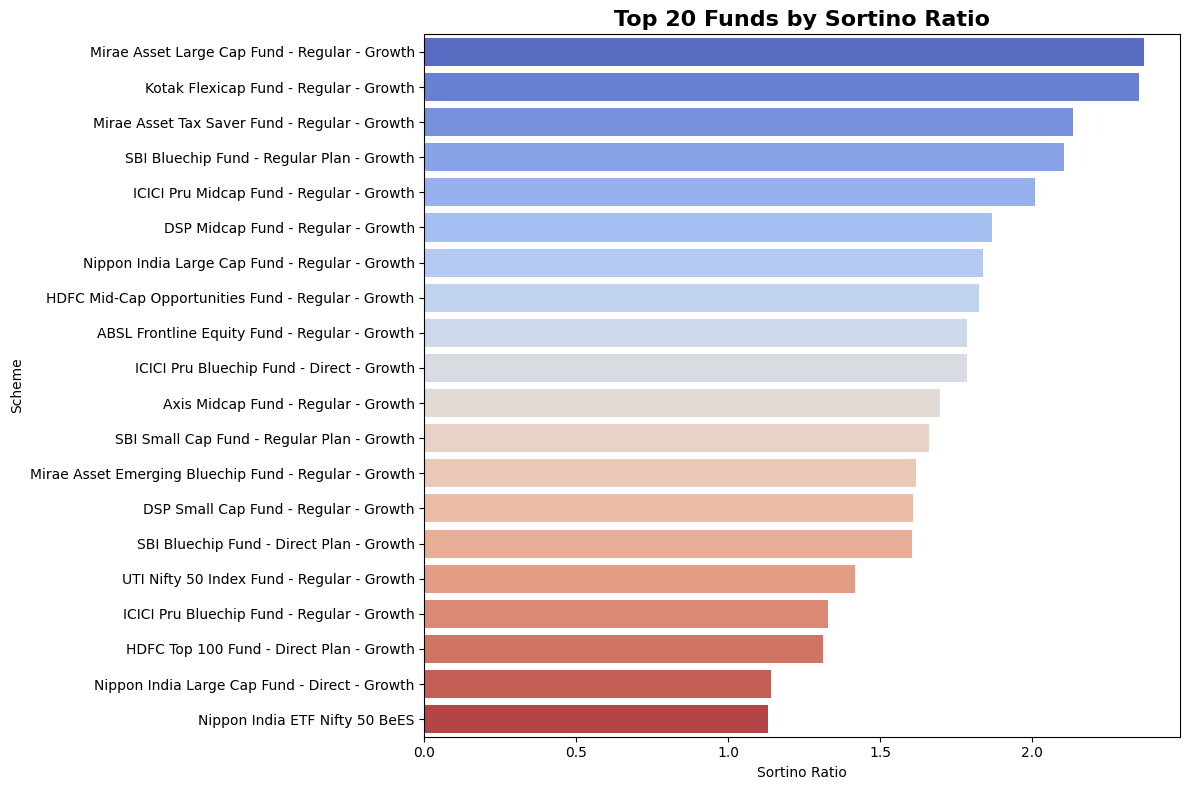

✅ Sortino Ratio computed!
 amfi_code                                           scheme_name  sortino_ratio  sortino_rank
    148567         Mirae Asset Large Cap Fund - Regular - Growth         2.3683             1
    120843                Kotak Flexicap Fund - Regular - Growth         2.3529             2
    148569         Mirae Asset Tax Saver Fund - Regular - Growth         2.1351             3
    119551             SBI Bluechip Fund - Regular Plan - Growth         2.1040             4
    120505              ICICI Pru Midcap Fund - Regular - Growth         2.0100             5
    149323                    DSP Midcap Fund - Regular - Growth         1.8689             6
    118632        Nippon India Large Cap Fund - Regular - Growth         1.8399             7
    100033    HDFC Mid-Cap Opportunities Fund - Regular - Growth         1.8238             8
    101206         ABSL Frontline Equity Fund - Regular - Growth         1.7856             9
    120504             ICICI Pru B

In [7]:
# Cell 5 — Sortino Ratio
RF = 0.065 / 252  # Daily risk-free rate

def sortino(group):
    excess = group - RF
    downside = excess[excess < 0]
    downside_std = downside.std()
    if downside_std == 0:
        return np.nan
    return (group.mean() - RF) / downside_std * np.sqrt(252)

sortino_df = returns_df.groupby('amfi_code')['daily_return'].apply(sortino).reset_index()
sortino_df.columns = ['amfi_code', 'sortino_ratio']
sortino_df = sortino_df.sort_values('sortino_ratio', ascending=False).reset_index(drop=True)
sortino_df['sortino_rank'] = sortino_df['sortino_ratio'].rank(ascending=False).astype(int)

# Merge scheme names
sortino_df = sortino_df.merge(performance_df[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
sortino_df = sortino_df[['amfi_code', 'scheme_name', 'sortino_ratio', 'sortino_rank']].round(4)

# Plot top 20
plt.figure(figsize=(12, 8))
top20_sortino = sortino_df.head(20)
sns.barplot(data=top20_sortino, x='sortino_ratio', y='scheme_name', palette='coolwarm')
plt.title('Top 20 Funds by Sortino Ratio', fontsize=16, fontweight='bold')
plt.xlabel('Sortino Ratio')
plt.ylabel('Scheme')
plt.tight_layout()
plt.savefig('charts/sortino_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Sortino Ratio computed!")
print(sortino_df.to_string(index=False))

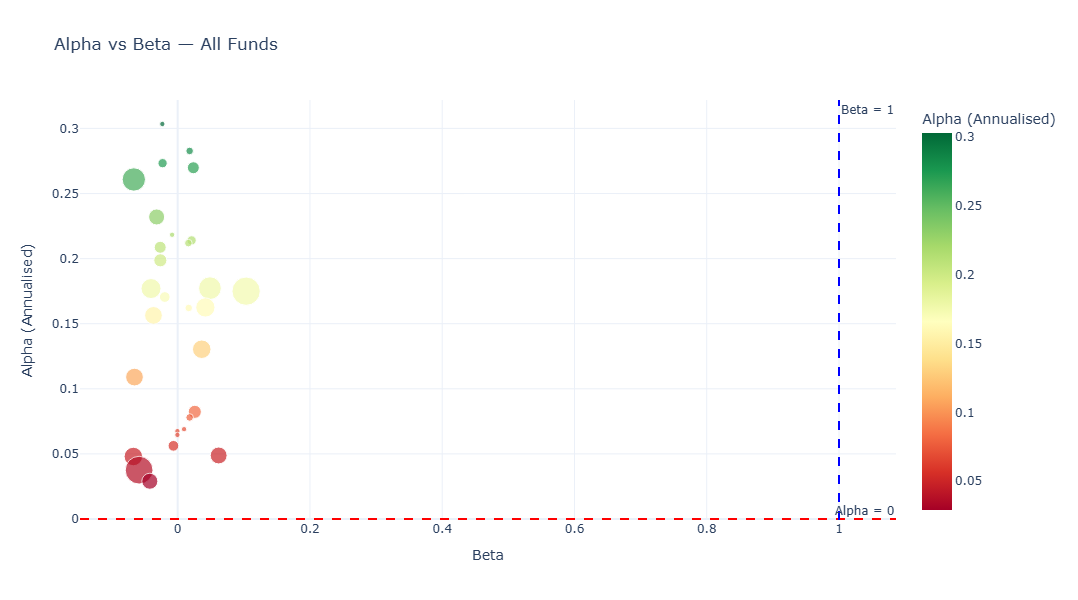

✅ Alpha & Beta computed and saved!
 amfi_code                                           scheme_name  alpha    beta  r_squared  alpha_rank
    119598            SBI Small Cap Fund - Regular Plan - Growth 0.3034 -0.0232     0.0001           1
    149324                 DSP Small Cap Fund - Regular - Growth 0.3006  0.0115     0.0000           2
    120505              ICICI Pru Midcap Fund - Regular - Growth 0.2926  0.0005     0.0000           3
    148569         Mirae Asset Tax Saver Fund - Regular - Growth 0.2827  0.0181     0.0002           4
    120843                Kotak Flexicap Fund - Regular - Growth 0.2733 -0.0228     0.0003           5
    100033    HDFC Mid-Cap Opportunities Fund - Regular - Growth 0.2720  0.0051     0.0000           6
    148567         Mirae Asset Large Cap Fund - Regular - Growth 0.2698  0.0237     0.0005           7
    149323                    DSP Midcap Fund - Regular - Growth 0.2660 -0.0025     0.0000           8
    119094                   Axis Midc

In [10]:
# Cell 6 — Alpha and Beta (OLS Regression vs Nifty 100)
benchmark_df['date'] = pd.to_datetime(benchmark_df['date'])

# Get Nifty 100 returns
nifty100 = benchmark_df[benchmark_df['index_name'] == 'NIFTY100'].copy()
nifty100 = nifty100.sort_values('date')
nifty100['benchmark_return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100.dropna(subset=['benchmark_return'])

alpha_beta_results = []

for amfi_code, group in returns_df.groupby('amfi_code'):
    merged = group[['date', 'daily_return']].merge(
        nifty100[['date', 'benchmark_return']], on='date', how='inner'
    )
    if len(merged) < 30:
        continue
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged['benchmark_return'], merged['daily_return']
    )
    alpha_beta_results.append({
        'amfi_code': amfi_code,
        'alpha': round(intercept * 252, 4),
        'beta': round(slope, 4),
        'r_squared': round(r_value ** 2, 4)
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)
alpha_beta_df = alpha_beta_df.merge(
    performance_df[['amfi_code', 'scheme_name']], on='amfi_code', how='left'
)
alpha_beta_df['alpha_rank'] = alpha_beta_df['alpha'].rank(ascending=False).astype(int)
alpha_beta_df = alpha_beta_df.sort_values('alpha', ascending=False).reset_index(drop=True)
alpha_beta_df = alpha_beta_df[['amfi_code', 'scheme_name', 'alpha', 'beta', 'r_squared', 'alpha_rank']]

# Plot Alpha vs Beta scatter
# Improved Alpha vs Beta chart
fig = px.scatter(
    alpha_beta_df,
    x='beta',
    y='alpha',
    hover_name='scheme_name',
    title='Alpha vs Beta — All Funds',
    labels={'alpha': 'Alpha (Annualised)', 'beta': 'Beta'},
    color='alpha',
    size='r_squared',
    color_continuous_scale='RdYlGn'
)
fig.add_hline(y=0, line_dash='dash', line_color='red', annotation_text='Alpha = 0')
fig.add_vline(x=1, line_dash='dash', line_color='blue', annotation_text='Beta = 1')
fig.update_traces(textposition='top center', textfont_size=8)
fig.update_layout(height=600, template='plotly_white')
fig.show()
fig.write_image("charts/alpha_beta.png")


# Save CSV
alpha_beta_df.to_csv('alpha_beta.csv', index=False)
print("✅ Alpha & Beta computed and saved!")
print(alpha_beta_df.to_string(index=False))

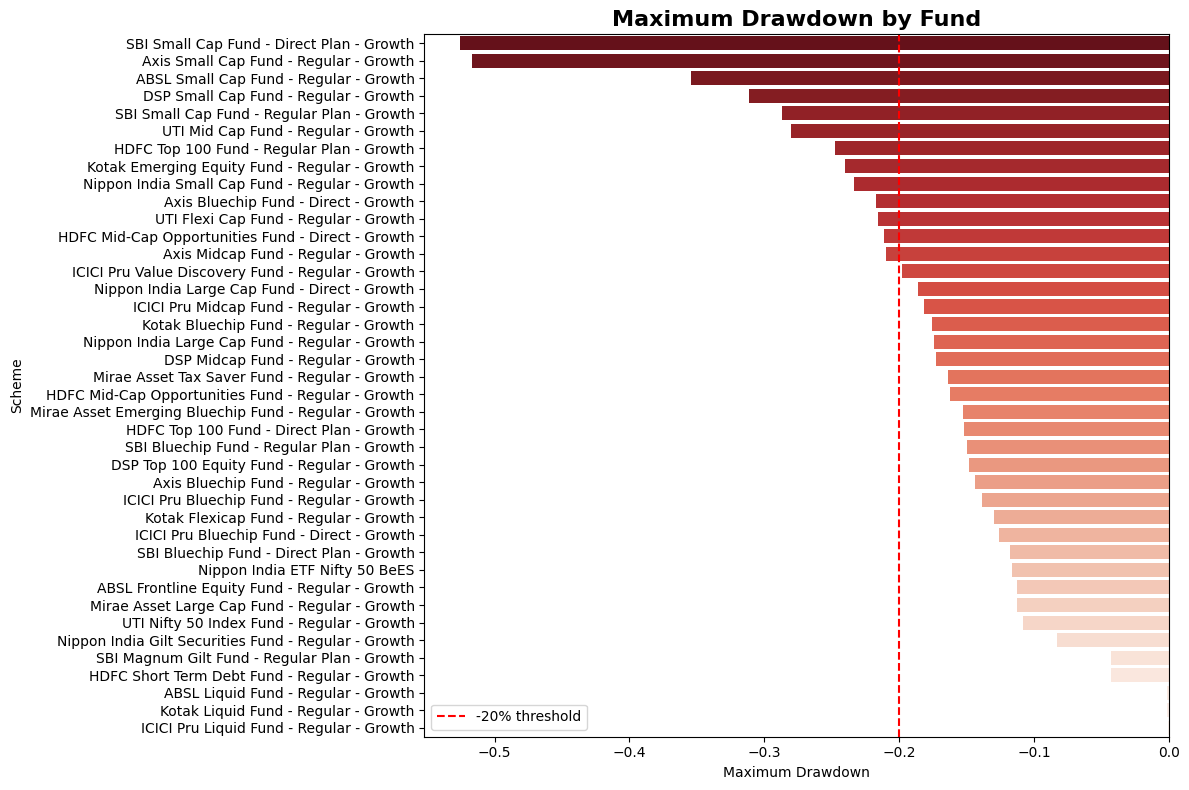

✅ Maximum Drawdown computed!
 amfi_code                                           scheme_name  max_drawdown max_dd_date  mdd_rank
    119599             SBI Small Cap Fund - Direct Plan - Growth       -0.5257  2025-10-28        40
    119095                Axis Small Cap Fund - Regular - Growth       -0.5168  2026-05-11        39
    101207                ABSL Small Cap Fund - Regular - Growth       -0.3545  2026-05-11        38
    149324                 DSP Small Cap Fund - Regular - Growth       -0.3117  2025-01-03        37
    119598            SBI Small Cap Fund - Regular Plan - Growth       -0.2871  2025-05-14        36
    102886                   UTI Mid Cap Fund - Regular - Growth       -0.2800  2026-04-27        35
    100016             HDFC Top 100 Fund - Regular Plan - Growth       -0.2473  2022-09-15        34
    120842         Kotak Emerging Equity Fund - Regular - Growth       -0.2400  2024-10-17        33
    118634        Nippon India Small Cap Fund - Regular - Grow

In [11]:
# Cell 7 — Maximum Drawdown
def max_drawdown(group):
    group = group.sort_values('date')
    rolling_max = group['nav'].cummax()
    drawdown = group['nav'] / rolling_max - 1
    max_dd = drawdown.min()
    max_dd_date = group.loc[drawdown.idxmin(), 'date']
    return pd.Series({'max_drawdown': round(max_dd, 4), 'max_dd_date': max_dd_date})

mdd_df = nav_df.groupby('amfi_code').apply(max_drawdown).reset_index()
mdd_df = mdd_df.merge(performance_df[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
mdd_df['mdd_rank'] = mdd_df['max_drawdown'].rank(ascending=False).astype(int)
mdd_df = mdd_df.sort_values('max_drawdown', ascending=True).reset_index(drop=True)
mdd_df = mdd_df[['amfi_code', 'scheme_name', 'max_drawdown', 'max_dd_date', 'mdd_rank']]

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(
    data=mdd_df,
    x='max_drawdown',
    y='scheme_name',
    palette='Reds_r'
)
plt.title('Maximum Drawdown by Fund', fontsize=16, fontweight='bold')
plt.xlabel('Maximum Drawdown')
plt.ylabel('Scheme')
plt.axvline(x=-0.2, color='red', linestyle='--', label='-20% threshold')
plt.legend()
plt.tight_layout()
plt.savefig('charts/max_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Maximum Drawdown computed!")
print(mdd_df.to_string(index=False))

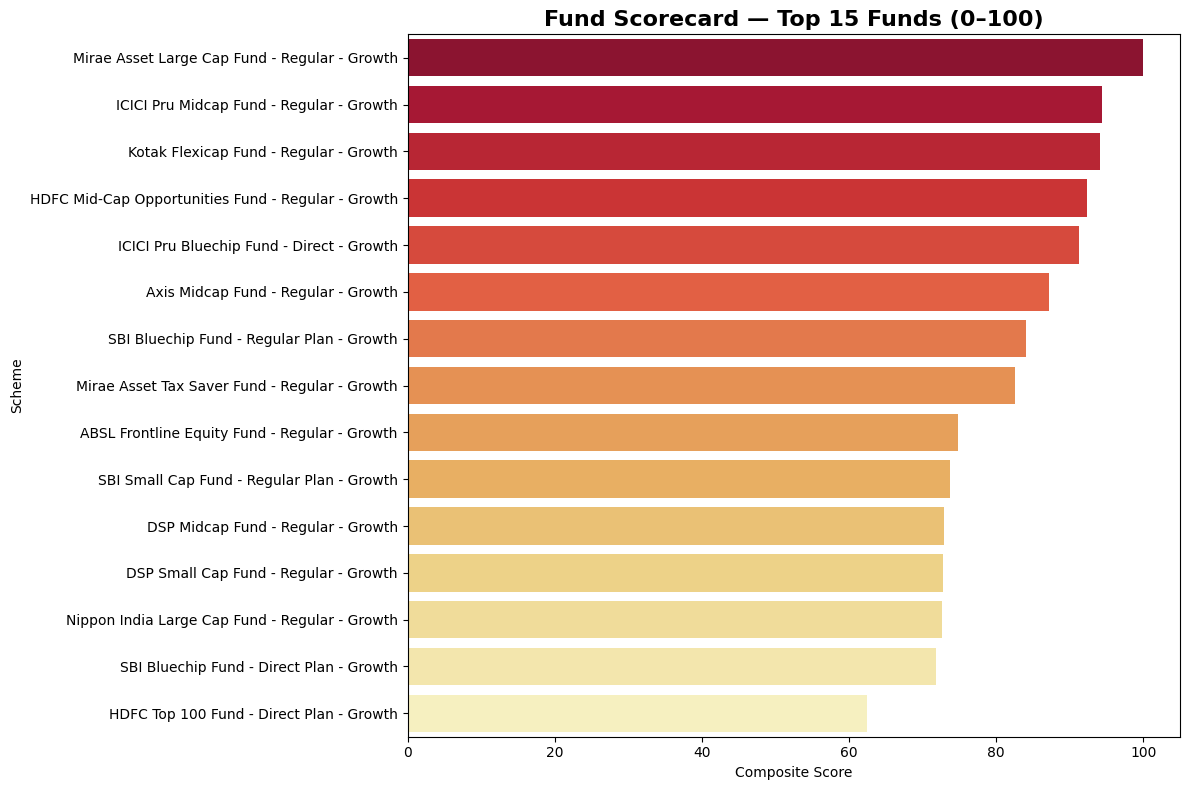

✅ Fund Scorecard computed and saved!
                                          scheme_name  score  final_rank
        Mirae Asset Large Cap Fund - Regular - Growth 100.00           1
             ICICI Pru Midcap Fund - Regular - Growth  94.44           2
               Kotak Flexicap Fund - Regular - Growth  94.09           3
   HDFC Mid-Cap Opportunities Fund - Regular - Growth  92.35           4
            ICICI Pru Bluechip Fund - Direct - Growth  91.31           5
                  Axis Midcap Fund - Regular - Growth  87.14           6
            SBI Bluechip Fund - Regular Plan - Growth  84.10           7
        Mirae Asset Tax Saver Fund - Regular - Growth  82.54           8
        ABSL Frontline Equity Fund - Regular - Growth  74.89           9
           SBI Small Cap Fund - Regular Plan - Growth  73.76          10
                   DSP Midcap Fund - Regular - Growth  72.89          11
                DSP Small Cap Fund - Regular - Growth  72.81          12
       Nippon 

In [12]:
# Cell 8 — Fund Scorecard (0-100)
# Merge all metrics
scorecard_df = cagr_df[['amfi_code', 'scheme_name', 'cagr_3yr']].copy()
scorecard_df = scorecard_df.merge(sharpe_df[['amfi_code', 'sharpe_rank']], on='amfi_code', how='left')
scorecard_df = scorecard_df.merge(alpha_beta_df[['amfi_code', 'alpha_rank']], on='amfi_code', how='left')
scorecard_df = scorecard_df.merge(mdd_df[['amfi_code', 'mdd_rank']], on='amfi_code', how='left')
scorecard_df = scorecard_df.merge(performance_df[['amfi_code', 'expense_ratio_pct']], on='amfi_code', how='left')

# Rank 3yr CAGR
scorecard_df['cagr_rank'] = scorecard_df['cagr_3yr'].rank(ascending=False)

# Expense ratio rank (inverse — lower is better)
scorecard_df['expense_rank'] = scorecard_df['expense_ratio_pct'].rank(ascending=True)

n = len(scorecard_df)

# Composite score (higher rank number = worse, so invert)
scorecard_df['score'] = (
    0.30 * (n + 1 - scorecard_df['cagr_rank']) +
    0.25 * (n + 1 - scorecard_df['sharpe_rank']) +
    0.20 * (n + 1 - scorecard_df['alpha_rank']) +
    0.15 * (n + 1 - scorecard_df['expense_rank']) +
    0.10 * (n + 1 - scorecard_df['mdd_rank'])
)

# Normalize to 0-100
scorecard_df['score'] = (
    (scorecard_df['score'] - scorecard_df['score'].min()) /
    (scorecard_df['score'].max() - scorecard_df['score'].min()) * 100
).round(2)

scorecard_df = scorecard_df.sort_values('score', ascending=False).reset_index(drop=True)
scorecard_df['final_rank'] = range(1, len(scorecard_df) + 1)

# Plot top 15
plt.figure(figsize=(12, 8))
sns.barplot(
    data=scorecard_df.head(15),
    x='score',
    y='scheme_name',
    palette='YlOrRd_r'
)
plt.title('Fund Scorecard — Top 15 Funds (0–100)', fontsize=16, fontweight='bold')
plt.xlabel('Composite Score')
plt.ylabel('Scheme')
plt.tight_layout()
plt.savefig('charts/fund_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()

# Save CSV
scorecard_df[['amfi_code', 'scheme_name', 'score', 'final_rank']].to_csv('fund_scorecard.csv', index=False)
print("✅ Fund Scorecard computed and saved!")
print(scorecard_df[['scheme_name', 'score', 'final_rank']].to_string(index=False))

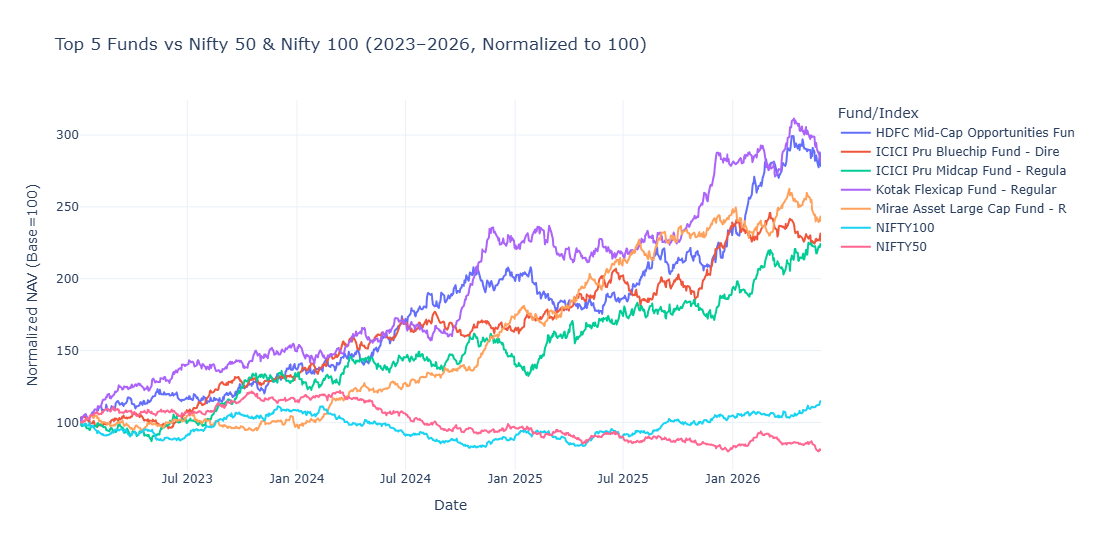


📊 Tracking Error vs Nifty 100:
  Mirae Asset Large Cap Fund - Regular - G: 0.1874
  ICICI Pru Midcap Fund - Regular - Growth: 0.2324
  Kotak Flexicap Fund - Regular - Growth: 0.2068
  HDFC Mid-Cap Opportunities Fund - Regula: 0.2266
  ICICI Pru Bluechip Fund - Direct - Growt: 0.1888

✅ Benchmark comparison chart saved!


In [13]:
# Cell 9 — Benchmark Comparison (Top 5 funds vs Nifty 50 & Nifty 100)
top5_codes = scorecard_df.head(5)['amfi_code'].tolist()
top5_names = scorecard_df.head(5).set_index('amfi_code')['scheme_name'].to_dict()

# Filter nav for top 5 funds — last 3 years
cutoff = pd.Timestamp('2023-01-01')
nav_top5 = nav_df[(nav_df['amfi_code'].isin(top5_codes)) & (nav_df['date'] >= cutoff)].copy()

# Normalize to 100 at start
def normalize(group):
    group = group.sort_values('date')
    group['nav_norm'] = group['nav'] / group['nav'].iloc[0] * 100
    return group

nav_top5 = nav_top5.groupby('amfi_code').apply(normalize).reset_index(drop=True)
nav_top5['label'] = nav_top5['amfi_code'].map(top5_names).str[:30]

# Normalize benchmarks
benchmarks = ['NIFTY50', 'NIFTY100']
bench_filtered = benchmark_df[
    (benchmark_df['index_name'].isin(benchmarks)) &
    (pd.to_datetime(benchmark_df['date']) >= cutoff)
].copy()
bench_filtered['date'] = pd.to_datetime(bench_filtered['date'])

bench_norm = []
for idx, group in bench_filtered.groupby('index_name'):
    group = group.sort_values('date')
    group['nav_norm'] = group['close_value'] / group['close_value'].iloc[0] * 100
    group['label'] = idx
    bench_norm.append(group[['date', 'nav_norm', 'label']])

bench_norm_df = pd.concat(bench_norm)

# Combine
fund_plot = nav_top5[['date', 'nav_norm', 'label']]
combined = pd.concat([fund_plot, bench_norm_df], ignore_index=True)

# Plot
fig = px.line(
    combined,
    x='date',
    y='nav_norm',
    color='label',
    title='Top 5 Funds vs Nifty 50 & Nifty 100 (2023–2026, Normalized to 100)',
    labels={'nav_norm': 'Normalized NAV (Base=100)', 'date': 'Date', 'label': 'Fund/Index'}
)
fig.update_layout(height=550, template='plotly_white')
fig.show()
fig.write_image("charts/benchmark_comparison.png")

# Tracking Error
print("\n📊 Tracking Error vs Nifty 100:")
nifty100_ret = nifty100[nifty100['date'] >= cutoff][['date', 'benchmark_return']].copy()

for code in top5_codes:
    fund_ret = returns_df[(returns_df['amfi_code'] == code) & (returns_df['date'] >= cutoff)][['date', 'daily_return']]
    merged = fund_ret.merge(nifty100_ret, on='date', how='inner')
    tracking_error = (merged['daily_return'] - merged['benchmark_return']).std() * np.sqrt(252)
    print(f"  {top5_names[code][:40]}: {tracking_error:.4f}")

print("\n✅ Benchmark comparison chart saved!")
